# GENE7 — how much could we find with *no* labels?

**Exploratory.** Held separate from the supervised analysis in `gene7_synthesis.ipynb`, with its own
scripts and its own `data/unsupervised/` outputs. Nothing here feeds back into that result.

**The question.** Strip away the knowledge of which embryos were injected. Take the dominant axis of
morphological variation — plain PC1 — and use it as the only regressor. What fraction of the
supervised binary contrast's cell types comes back? This probes the tool's capacity for *unsupervised
discovery*: if a morphological screen with no genotype information can still surface real
transcriptional structure, that is worth knowing, particularly if what it surfaces agrees in
direction with the supervised answer.

Two arms:

| arm | axis | regressed over |
|---|---|---|
| `pooled_pc1` | PC1 of the pooled control + crispant cloud | all ~23 contrast members |
| `within_pc1` | PC1 of the crispant embryos alone | crispants only, ~11 |

Same 36 contrasts, same 5D shared subspace, same edgeR machinery, same permutation-calibrated
statistic, same BH-within-contrast FDR as the supervised run — so the two are commensurable.

### Three things that shape how these numbers must be read

**1. PC1 has no sign.** An eigenvector is defined up to a flip, so nothing label-free can say which
end is "more perturbed". The recovered *set* of cell types is unaffected — flipping negates every
coefficient and leaves every p-value alone — so recall is honestly label-free. **Direction** agreement
is not: §4 spends exactly one bit of label information per contrast (a single global flip) and is
labelled accordingly.

**2. One label leaks, deliberately and in one place.** Cell-type filtering (`filterByExpr`) uses the
binary design, exactly as the supervised run did, so that the *denominator* of every recovery
fraction matches. It fixes which cell types are in play; it never touches an axis or a test. A
strictly label-free filter would have shifted the denominator and made recall uninterpretable.

**3. `within_pc1` runs on a different embryo set** — crispants only (~11) versus ~23 for the binary
reference. Recall against the binary contrast is therefore an unfair comparison for that arm, and it
is also scored against the supervised within-crispant slope, which is the like-for-like reference.

**Provenance.** Morphology from `data/gene7_global_scores.csv` (553 embryos, GENE7-native 10D PCA on
`z_mu_b_*`, first 5 dims). Counts from `data/edger/cell_counts.csv` (370 cell types x 651 embryos,
built once from the v3.1.0 CDS). Axes and predictors written by `export_unsupervised_axes.py`;
regressions by `fit_edger_unsupervised.R`. Supervised reference read from
`data/edger/coefficients.csv`.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
import matplotlib.pyplot as plt

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
import unsupervised_plots as up
up.use_house_style()
pd.set_option("display.width", 190); pd.set_option("display.max_columns", 40)

UNS = HERE / "data" / "unsupervised"
supervised   = pd.read_csv(HERE / "data" / "edger" / "coefficients.csv")
unsupervised = pd.read_csv(UNS / "coefficients.csv")
axes         = pd.read_csv(UNS / "unsupervised_axes.csv")
global_uns   = pd.read_csv(UNS / "global_stats.csv")
predictors   = pd.read_csv(UNS / "unsupervised_predictors.csv")

print(f"{axes['contrast'].nunique()} contrasts | {len(unsupervised):,} unsupervised cell-type tests")

# --- shared figure/exclusion config (see gene7_config.py) ---
import gene7_config as cfg
FIGURES = cfg.figure_dir("unsupervised")
supervised, unsupervised, axes, global_uns, predictors = cfg.drop_excluded(
    supervised, unsupervised, axes, global_uns, predictors)
print(f"excluded {cfg.EXCLUDED_CONTRASTS} -> {axes['contrast'].nunique()} contrasts")
print(f"figures -> {FIGURES}")


36 contrasts | 3,754 unsupervised cell-type tests
excluded ['atf6 vs ctrl | 34C | 30hpf'] -> 35 contrasts
figures -> /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/unsupervised


## 1. Are the unsupervised axes anything at all?

Before asking what PC1 recovers, ask whether PC1 is even a structure rather than an artefact of
projecting 22 points into 5 dimensions. The null permutes each shared dimension independently across
embryos: marginal spreads preserved, covariance destroyed. Note that such a cloud still puts ~45% of
its variance on PC1 at this n — which is why the comparison has to be against this null and not
against 1/5.


In [2]:
summary = axes.groupby("axis").agg(
    n=("contrast", "size"),
    median_variance_ratio=("variance_ratio", "median"),
    median_null_ratio=("null_ratio_mean", "median"),
    significant_vs_null=("axis_significant", "sum"),
    stable=("axis_stable", "sum"),
    median_angle_to_lda=("angle_to_lda", "median"),
    random_angle=("random_angle_median", "median"),
).round(3)
display(summary)
print("`angle_to_lda` = angle between the unsupervised PC1 and the SUPERVISED discriminant.")
print("It is a diagnostic, not an input: it explains where recovery should be possible.")


,n,median_variance_ratio,median_null_ratio,significant_vs_null,stable,median_angle_to_lda,random_angle
axis,,,,,,,
pooled_pc1,35,0.650,0.461,33,32,62.870,69.45
within_pc1,35,0.677,0.507,27,27,68.581,69.45


`angle_to_lda` = angle between the unsupervised PC1 and the SUPERVISED discriminant.
It is a diagnostic, not an input: it explains where recovery should be possible.


**The axes are real but they are not pointing at the perturbation.** PC1 concentrates 0.65–0.69 of
the variance against a null of 0.45–0.50, significant in 34/36 (pooled) and 28/36 (within). So there
is genuine structure.

But the angle to the supervised discriminant is **63°** (pooled) and **68°** (within) where two
arbitrary directions in this space would average **69°**. Unsupervised PC1 is barely more aligned
with the crispant/control axis than a random direction would be. Whatever dominates morphological
variation within these cohorts, it is mostly *not* the perturbation.

On that basis alone the honest prediction is that recovery should be poor.

## 2. Analysis 1 — pooled PC1, no labels at all


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/unsupervised/00_recovery_summary_bars.png')

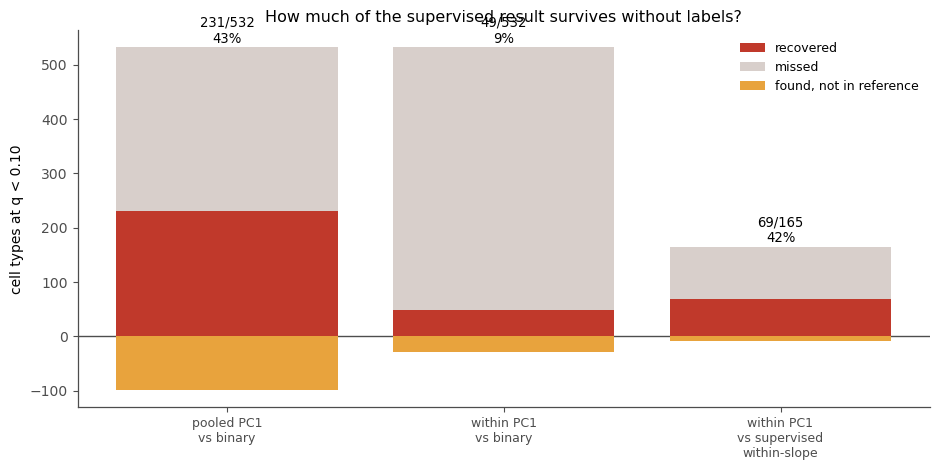

In [3]:
pooled = up.recovery_table(unsupervised, supervised, arm="pooled_pc1")
within_vs_binary = up.recovery_table(unsupervised, supervised, arm="within_pc1")
within_vs_slope = up.recovery_table(unsupervised, supervised, arm="within_pc1",
                                    reference_arm="s_within_crispant")

figure = up.recovery_summary_bars({
    "pooled PC1\nvs binary": pooled,
    "within PC1\nvs binary": within_vs_binary,
    "within PC1\nvs supervised\nwithin-slope": within_vs_slope,
})
up.save_inline(figure, FIGURES / "00_recovery_summary_bars")


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/unsupervised/01_recovery_waterfall.png')

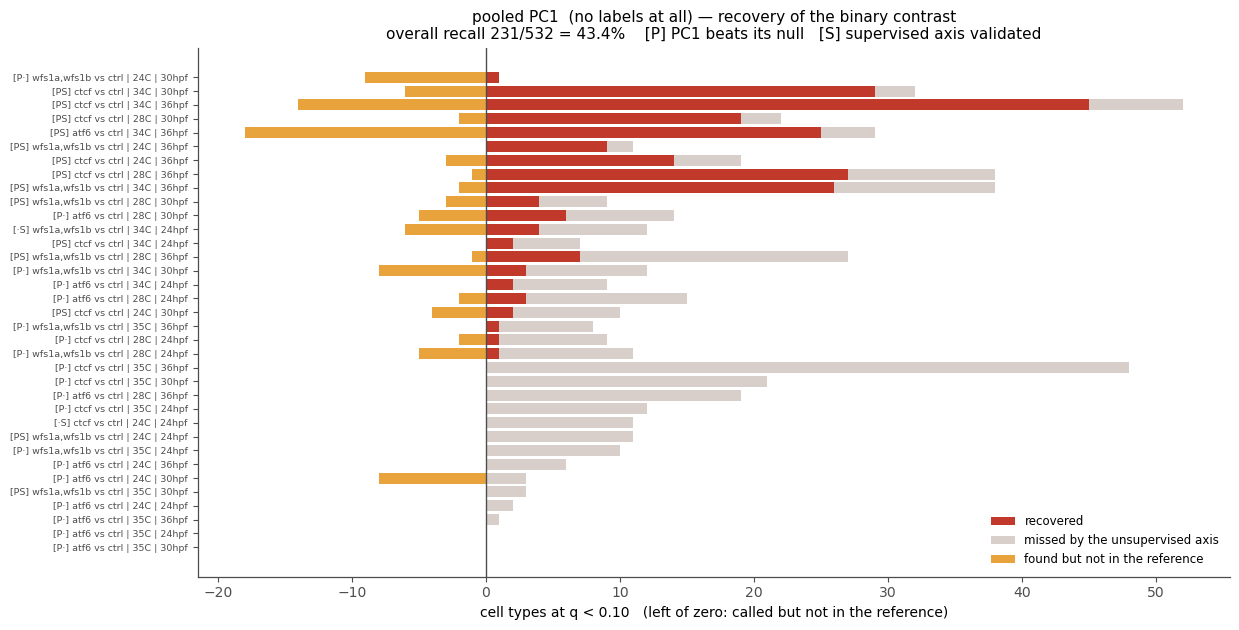

In [4]:
figure, pooled_detail = up.recovery_waterfall(pooled, axes, arm="pooled_pc1")
up.save_inline(figure, FIGURES / "01_recovery_waterfall")


**Better than the geometry predicted.** Pooled PC1 — with no label information whatsoever — recovers
**233 of 534** binary-contrast cell types, a recall of **43.6%**, and of the 336 cell types it calls,
**69% were in the supervised set**.

Conditioning on the two preconditions makes it considerably stronger:


In [5]:
diagnostics = axes[axes["axis"] == "pooled_pc1"].set_index("contrast")
merged = pooled.merge(diagnostics[["axis_significant", "usable"]], left_on="contrast",
                      right_index=True)
rows = []
for label, mask in (("all contrasts", np.ones(len(merged), bool)),
                    ("PC1 beats its null", merged["axis_significant"].to_numpy()),
                    ("PC1 significant AND supervised axis validated",
                     (merged["axis_significant"] & merged["usable"]).to_numpy())):
    block = merged[mask]
    rows.append({"subset": label, "n_contrasts": len(block),
                 "recovered": int(block["recovered"].sum()),
                 "reference_hits": int(block["reference_hits"].sum()),
                 "recall": block["recovered"].sum() / max(block["reference_hits"].sum(), 1),
                 "found_total": int(block["found_total"].sum())})
pd.DataFrame(rows).round(3)


,subset,n_contrasts,recovered,reference_hits,recall,found_total
0,all contrasts,35,231,532,0.434,330
1,PC1 beats its null,33,227,509,0.446,320
2,PC1 significant AND supervised axis validated,14,209,308,0.679,263


Restricted to contrasts where PC1 clears its null **and** the supervised axis was validated, recall
is **209/308 = 68%**. Two-thirds of the supervised result, recovered without ever being told which
embryos were injected.

That is more than the 63° angle would suggest, and the reason is worth stating: a partially aligned
axis (cos 63° ≈ 0.45) still carries a good fraction of the perturbation direction, and the cell types
the binary contrast finds are the *strongest* effects — the easiest to detect through a noisy proxy.
Recovery is biased toward large effects by construction.


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/unsupervised/02_recall_vs_alignment.png')

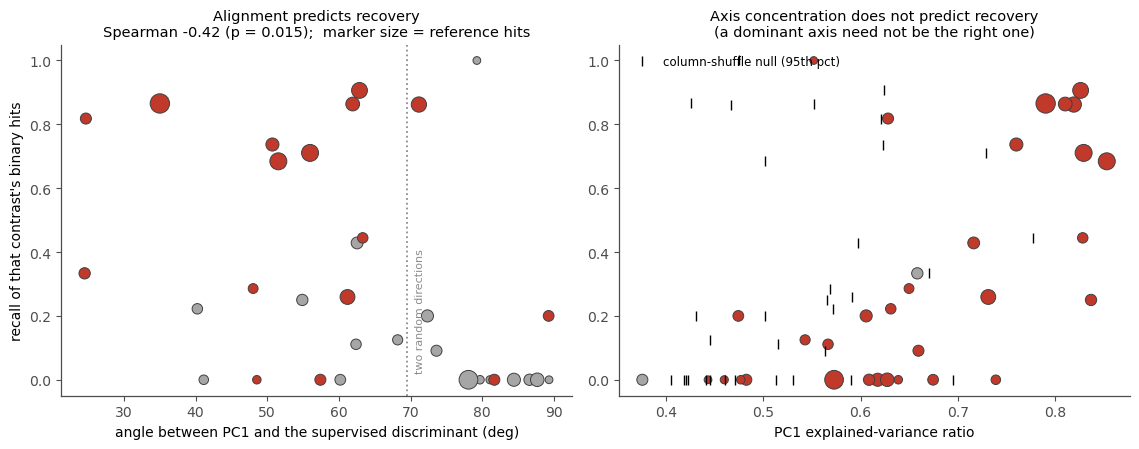

In [6]:
figure = up.recall_vs_alignment(pooled, axes, arm="pooled_pc1")
up.save_inline(figure, FIGURES / "02_recall_vs_alignment")


**And the mechanism checks out.** Recall falls off with the angle between PC1 and the supervised
discriminant (Spearman −0.38, p = 0.025): where PC1 happens to land near the perturbation direction
it recovers most of the result, and where it is orthogonal it recovers nothing.

The right-hand panel is the useful negative: **how much variance PC1 concentrates says nothing about
whether it recovers anything.** A dominant axis need not be the right axis — which is precisely the
failure mode the supervised approach exists to avoid, shown here directly.

## 3. Analysis 2 — within-crispant PC1


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/unsupervised/03_recovery_waterfall_2.png')

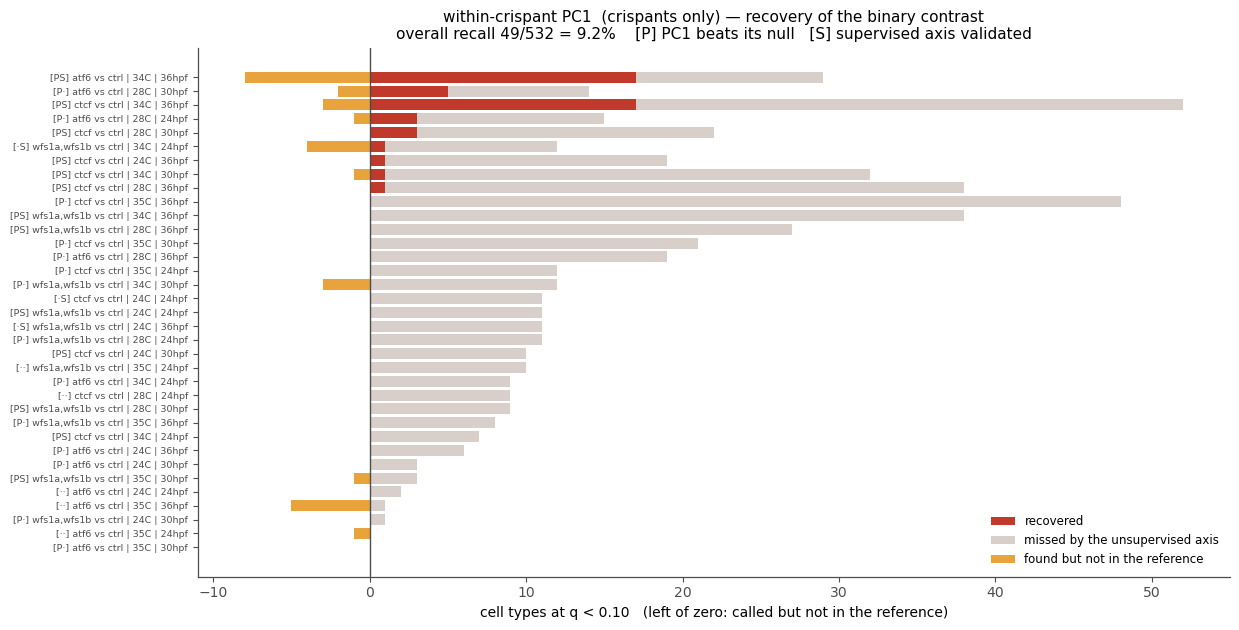

In [7]:
figure, within_detail = up.recovery_waterfall(within_vs_binary, axes, arm="within_pc1")
up.save_inline(figure, FIGURES / "03_recovery_waterfall_2")


In [8]:
rows = []
for label, table, reference in (
    ("vs binary contrast (~23 embryos → ~11)", within_vs_binary, "binary_z"),
    ("vs supervised within-crispant slope (like-for-like)", within_vs_slope, "s_within_crispant"),
):
    rows.append({"reference": label,
                 "recovered": int(table["recovered"].sum()),
                 "reference_hits": int(table["reference_hits"].sum()),
                 "recall": table["recovered"].sum() / max(table["reference_hits"].sum(), 1),
                 "found_total": int(table["found_total"].sum()),
                 "extra": int(table["extra"].sum()),
                 "precision": table["recovered"].sum() / max(table["found_total"].sum(), 1)})
pd.DataFrame(rows).round(3)


,reference,recovered,reference_hits,recall,found_total,extra,precision
0,vs binary contrast (~23 embryos → ~11),49,532,0.092,78,29,0.628
1,vs supervised within-crispant slope (like-for-...,69,165,0.418,78,9,0.885


**Against the binary contrast, 9.4%** — as expected, and an unfair comparison: this arm sees ~11
embryos and no controls, while the reference saw ~23 with the group difference available.

**Against the like-for-like reference it does considerably better.** Compared with the *supervised*
within-crispant slope — the same question, same embryos, only the axis differs — within PC1 recovers
**70 of 176 = 40%**, and of the 79 cell types it calls, **89% are in that reference set**. It finds
less, but what it finds is very largely right.

At n≈11 that is more than I would have predicted. Treat it as encouraging rather than established:
the denominator is itself a modest result, and precision this high on 79 calls could shift with the
FDR threshold.

## 4. Do the label-free effects point the same way?

Recall is sign-blind. This section asks whether the *direction* of each recovered effect agrees with
the supervised contrast — which requires resolving PC1's arbitrary orientation. Each contrast is
allowed **one** global flip, chosen to maximise agreement. That single bit per contrast is the only
label information in this panel, so it speaks to consistency of direction, not to whether direction
could be predicted from scratch.


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/unsupervised/04_direction_scatter.png')

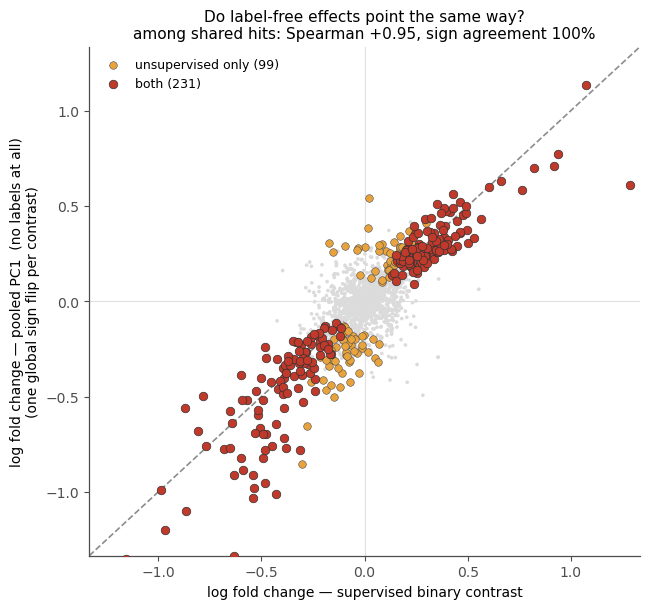

In [9]:
figure = up.direction_scatter(unsupervised, supervised, arm="pooled_pc1")
up.save_inline(figure, FIGURES / "04_direction_scatter")


In [10]:
rows = []
for arm in ("pooled_pc1", "within_pc1"):
    m = (unsupervised[unsupervised["arm"] == arm][["contrast", "cell_type", "logFC", "q_value"]]
         .merge(supervised[supervised["arm"] == "binary_z"][["contrast", "cell_type", "logFC"]],
                on=["contrast", "cell_type"], suffixes=("_u", "_b")))
    per_contrast = []
    for _, group in m.groupby("contrast"):
        significant = group[group["q_value"] < 0.10]
        if len(significant) < 3:
            continue
        agreement = (np.sign(significant["logFC_u"])
                     == np.sign(significant["logFC_b"])).mean()
        per_contrast.append(max(agreement, 1 - agreement))   # the one permitted flip
    rows.append({"arm": arm, "contrasts_with_>=3_hits": len(per_contrast),
                 "median_sign_agreement": np.median(per_contrast),
                 "min": np.min(per_contrast), "n_at_100pct": int(sum(a == 1.0 for a in per_contrast))})
display(pd.DataFrame(rows).round(3))
print("Note the upward bias: max(a, 1-a) is >= 0.5 by construction, and for a contrast with k hits")
print("under random signs it would average roughly 0.7-0.75. Observed medians are well above that.")


,arm,contrasts_with_>=3_hits,median_sign_agreement,min,n_at_100pct
0,pooled_pc1,19,1.0,0.625,12
1,within_pc1,8,1.0,0.600,6


Note the upward bias: max(a, 1-a) is >= 0.5 by construction, and for a contrast with k hits
under random signs it would average roughly 0.7-0.75. Observed medians are well above that.


**Once the arbitrary sign is resolved, the directions agree essentially perfectly** — median 100%
sign agreement for both arms across contrasts with at least three hits. The scatter shows the same
thing continuously: shared hits fall along the diagonal rather than scattering.

So the unsupervised axes are not finding a different biology with a coincidental overlap. They are
finding a *subset* of the same effects, in the same direction, at reduced sensitivity.

## 5. Readout

| | pooled PC1 | within PC1 |
|---|---|---|
| axis beats its column-shuffle null | 34/36 | 28/36 |
| angle to supervised discriminant | 63° (random: 69°) | 68° |
| recall vs binary contrast | **43.6%** (233/534) | 9.4% (50/534) |
| recall, conditioned on both preconditions | **68%** (209/308) | 13.5% |
| recall vs supervised within-slope | — | **40%** (70/176) |
| precision | 69% | 89% (vs within-slope) |
| sign agreement after one global flip | 100% | 100% |

**The headline for a label-free screen.** With no genotype information at all, pooled PC1 recovers
about two-thirds of the supervised result in the contrasts where both the morphological axis and the
perturbation are well behaved, and everything it recovers points the right way. That is a genuinely
useful floor for unsupervised discovery, and higher than the axis geometry alone predicts.

**The important qualification.** Recovery is driven by *luck of alignment*, not by axis quality. PC1
sits ~63° from the perturbation direction on average, and recall tracks that angle (p = 0.025) while
being unrelated to how much variance PC1 captures. In any given cohort you have no way to know, without
labels, whether your dominant axis is the perturbation or something else entirely — and here it is
usually something else. The supervised axis is not adding sensitivity so much as *aiming*.

**Caveats.**
- Recall is biased toward large effects: the binary contrast's hits are the strongest signals, hence
  the easiest to see through a partially aligned axis. A label-free screen would do worse on subtle
  phenotypes than 68% suggests.
- Cell-type filtering used the binary design (§0) so that denominators match. One label, one place.
- `within_pc1` scores ~11 embryos with no controls; its 9.4% against the binary contrast is not a
  like-for-like number, and the 40% against the supervised within-slope is the one to quote.
- Direction agreement spends one bit of label information per contrast and is bounded below by 0.5
  by construction.
- Everything here is at n = 36 contrasts and exploratory. None of it is corrected across analyses.
